Accuracy: 0.651685393258427
Theta: [-0.25216033  1.20522885]


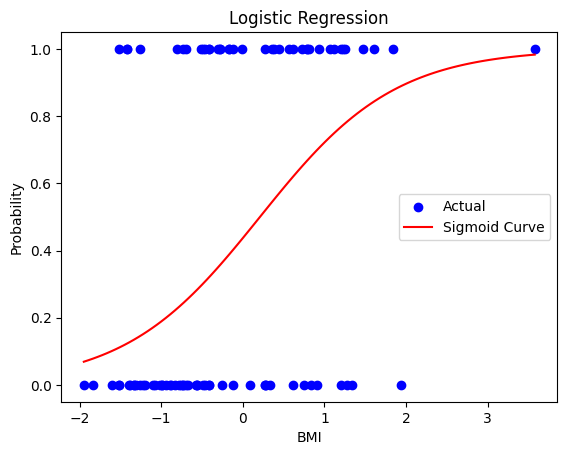

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
diabetes = load_diabetes()
X = diabetes.data[:, 2].reshape(-1, 1)  # BMI feature
y = diabetes.target

# Convert to binary classification
y_binary = (y > np.mean(y)).astype(int)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Add bias term (x0 = 1)
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Initialize parameters
theta = np.zeros(X_train.shape[1])

# Hyperparameters
learning_rate = 0.1
iterations = 1000

# Gradient Descent
for _ in range(iterations):
    z = np.dot(X_train, theta)
    h = sigmoid(z)

    gradient = np.dot(X_train.T, (h - y_train)) / y_train.size
    theta -= learning_rate * gradient

# Predictions
z_test = np.dot(X_test, theta)
y_pred_prob = sigmoid(z_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

# Accuracy
accuracy = np.mean(y_pred == y_test)
print("Accuracy:", accuracy)
print("Theta:", theta)

# Plot decision boundary
plt.scatter(X_test[:, 1], y_test, color="blue", label="Actual")

x_values = np.linspace(X_test[:,1].min(), X_test[:,1].max(), 100)
y_values = sigmoid(theta[0] + theta[1] * x_values)

plt.plot(x_values, y_values, color="red", label="Sigmoid Curve")
plt.xlabel("BMI")
plt.ylabel("Probability")
plt.title("Logistic Regression")
plt.legend()
plt.show()